In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D


In [2]:
STAT_PATH = "../experiments"
WORKUNITS_CREATION_NAME = os.path.join("exp", "workunits_creation")
TASK_DYNAMIC_NAME = os.path.join("exp", "task_dynamic")
EXP_NAME = "run_"
RUN_FOLDER = None


In [3]:
def load_app_series(file_path, value_name):
    df = pd.read_csv(file_path, sep=r"\s+", header=None, names=["application", value_name])
    df["application"] = df["application"].astype(int)
    df["second"] = df.groupby("application").cumcount()
    df["time_hours"] = df["second"] / 3600.0
    df["cumulative"] = df.groupby("application")[value_name].cumsum()
    return df

def load_run_series(run_path):
    created_path = os.path.join(run_path, WORKUNITS_CREATION_NAME)
    validated_path = os.path.join(run_path, TASK_DYNAMIC_NAME)
    created = load_app_series(created_path, "created")
    validated = load_app_series(validated_path, "validated")
    return created, validated

def plot_apps_workunits(ax, created, validated, title):
    applications = sorted(set(created["application"]).union(validated["application"]))
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    color_map = {app: colors[index % len(colors)] for index, app in enumerate(applications)}

    for app in applications:
        created_app = created[created["application"] == app]
        validated_app = validated[validated["application"] == app]
        ax.plot(
            created_app["time_hours"],
            created_app["cumulative"],
            color=color_map[app],
            linestyle="-",
        )
        ax.plot(
            validated_app["time_hours"],
            validated_app["cumulative"],
            color=color_map[app],
            linestyle="--",
        )

    type_handles = [
        Line2D([0], [0], color="black", linestyle="-", label="Total"),
        Line2D([0], [0], color="black", linestyle="--", label="Validated"),
    ]
    app_handles = [
        Line2D([0], [0], color=color_map[app], linestyle="-", label=str(app))
        for app in applications
    ]

    type_legend = ax.legend(handles=type_handles, title="Workunit type", loc="upper left")
    ax.add_artist(type_legend)
    ax.legend(handles=app_handles, title="Application", loc="upper right")
    ax.set_title(title)
    ax.set_xlabel("Time, hours")
    ax.set_ylabel("Cumulative workunits, units")
    ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.5)


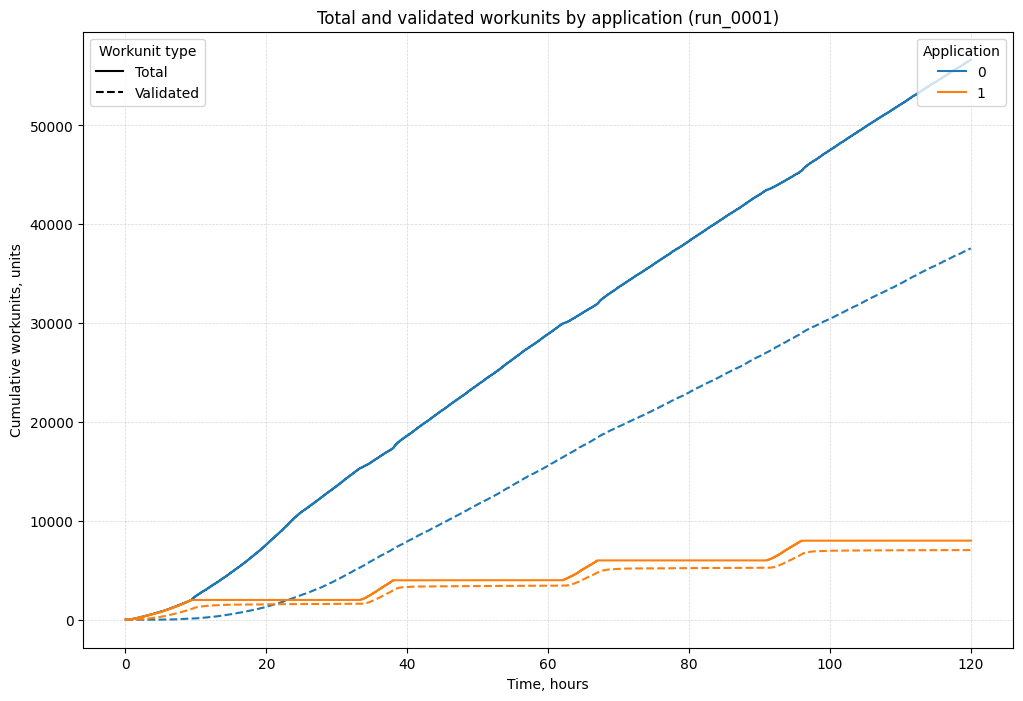

In [4]:
folders = sorted(
    f
    for f in os.listdir(STAT_PATH)
    if os.path.isdir(os.path.join(STAT_PATH, f)) and f.startswith(EXP_NAME)
)

if not folders:
    print(f"there is no folders in {STAT_PATH}")
else:
    selected_folder = RUN_FOLDER or folders[-1]
    if selected_folder not in folders:
        print(f"skip {selected_folder}: folder not found")
    else:
        run_path = os.path.join(STAT_PATH, selected_folder)
        created_path = os.path.join(run_path, WORKUNITS_CREATION_NAME)
        validated_path = os.path.join(run_path, TASK_DYNAMIC_NAME)
        if not os.path.exists(created_path):
            print(f"skip {selected_folder}: {WORKUNITS_CREATION_NAME} not found")
        elif not os.path.exists(validated_path):
            print(f"skip {selected_folder}: {TASK_DYNAMIC_NAME} not found")
        else:
            created, validated = load_run_series(run_path)
            fig, ax = plt.subplots(figsize=(12, 8))
            plot_apps_workunits(
                ax,
                created,
                validated,
                f"Total and validated workunits by application ({selected_folder})",
            )
            plt.show()
